In [ ]:
import abtem
import ase
import numpy as np
import cupy as cp

In [ ]:
abtem.config.set({"device": "gpu"})

In [ ]:
abtem.config.config

{'device': 'gpu',
 'fft': 'fftw',
 'precision': 'float32',
 'diagnostics': {'progress_bar': 'tqdm', 'task_progress': False},
 'dask': {'lazy': True, 'chunk-size': '128 MB', 'chunk-size-gpu': '512 MB'},
 'cupy': {'fft-cache-size': '0 MB'},
 'mkl': {'threads': 2},
 'fftw': {'threads': 1,
  'planning_effort': 'FFTW_MEASURE',
  'planning_timelimit': 60,
  'allow_fallback': True},
 'warnings': {'dask-blockwise-performance': False, 'overspecified-grid': True},
 'antialias': {'cutoff': 0.6666666, 'taper': 0.01},
 'visualize': {'real_space_units': 'Angstrom',
  'reciprocal_space_units': 'Angstrom',
  'cmap': 'viridis',
  'phase_cmap': 'hsluv',
  'continuous_update': False,
  'autoscale': False,
  'use_tex': True}}

In [4]:
r = 1

Lx, Ly, Lz = 50, 49, 4

period = 2 * np.pi / 3

pos = np.array([0, 1, 2])
pos = np.array([r*np.cos(period*pos), r*np.sin(period*pos), pos*Lz/3]).T
pos[:, 0] += Lx/2
pos[:, 1] += Ly/2

atoms = ase.Atoms('Au3', positions=pos, cell=[Lx, Ly, Lz], pbc=[1, 1, 1])

In [5]:
pos

array([[26.        , 24.5       ,  0.        ],
       [24.5       , 25.3660254 ,  1.33333333],
       [24.5       , 23.6339746 ,  2.66666667]])

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

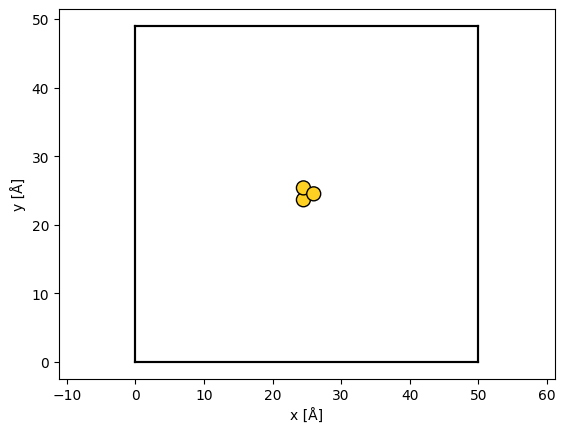

In [6]:
atoms = abtem.orthogonalize_cell(atoms)
sc = atoms*(1, 1, 10)
abtem.show_atoms(atoms)

In [7]:
potential = abtem.Potential(sc, sampling=0.05)

probe = abtem.Probe(energy=60e3, semiangle_cutoff=30)
probe.grid.match(potential)

(20.0, 30.0)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


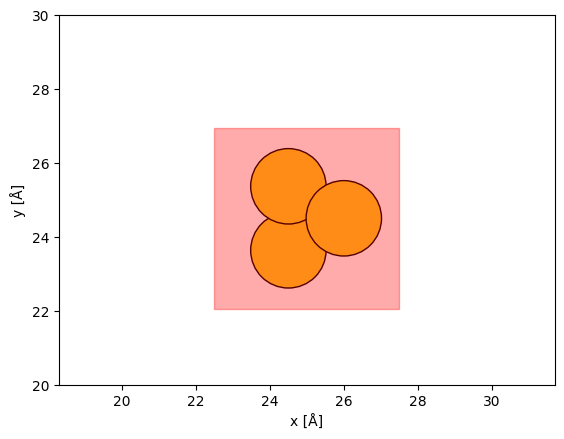

In [8]:
grid_scan = abtem.GridScan(
    start=[0.45, 0.45],
    end=[0.55, 0.55],
    sampling=probe.aperture.nyquist_sampling,
    fractional=True,
    potential=potential,
)

fig, ax = abtem.show_atoms(atoms)
grid_scan.add_to_plot(ax)
ax.set_xlim(left=20, right=30)
ax.set_ylim(bottom=20, top=30)

In [9]:
bright = abtem.AnnularDetector(inner=0, outer=30)
maadf = abtem.AnnularDetector(inner=50, outer=120)
haadf = abtem.AnnularDetector(inner=90, outer=200)
waves_detector = abtem.WavesDetector()

all_detectors = [bright, maadf, haadf, waves_detector]

measurements = probe.scan(
    potential, detectors=all_detectors, scan=grid_scan,
).compute();

tasks:   0%|          | 0/86 [00:00<?, ?it/s]

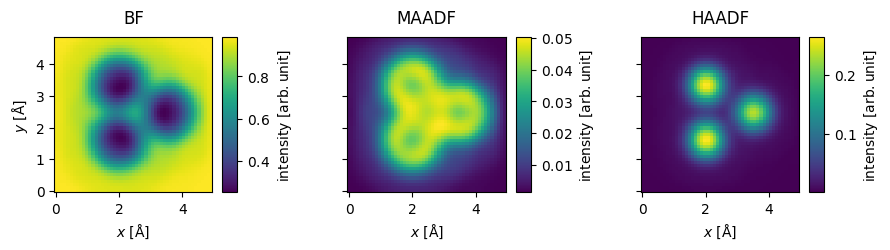

In [10]:
measurements1 = abtem.stack(measurements[:3], ("BF", "MAADF", "HAADF")).interpolate(sampling=0.1)

measurements1.show(explode=True, cbar=True, figsize=(10, 5));

In [50]:
waves = measurements[-1].diffraction_patterns(return_complex=True, max_angle=300).to_cpu().compute()

In [31]:
dp.shape

(13, 13, 619, 607)

In [51]:
QX, QY = np.meshgrid(*waves.angular_coordinates, indexing='ij')

In [ ]:
make det

In [55]:
mom1 = [dp.to_data_array()*np.sqrt(QX), dp.to_data_array()*np.sqrt(QY)]

#mom1 = abtem.stack(
#    [waves.from_array_and_metadata(mom1[0].data, dp.axes_metadata), 
#     waves.from_array_and_metadata(mom1[1].data, dp.axes_metadata)],
#)

/tmp/ipykernel_950/2801979925.py:1: RuntimeWarning: invalid value encountered in sqrt
  mom1 = [dp.to_data_array()*np.sqrt(QX), dp.to_data_array()*np.sqrt(QY)]


In [54]:
bright.apply(mom1)

AttributeError: 'DiffractionPatterns' object has no attribute 'diffraction_patterns'

In [39]:
tmp = mom1[0]